In [1]:
import os 
import sys

running_path = "/Odyssey/private/o23gauvr/code/"
os.chdir(running_path)
sys.path.insert(0,running_path)

In [2]:
import torch
import xarray as xr
import numpy as np 
import hydra
import yaml
import inspect
from IPython.display import Markdown, display
from omegaconf import OmegaConf
import pytorch_lightning as pl
from collections import namedtuple
import functools as ft
#from src.data import AugmentedDataset, XrDataset

In [2]:
gpu = 0  #*gpu:Union[None,int]

if torch.cuda.is_available() and gpu is not None:
  dev = f"cuda:{gpu}"
else:
  dev = "cpu"
device = torch.device(dev)

print(device)

#torch.set_default_device(device)

cuda:0


# eNATL vs NATL

In [3]:
#sound_speed_path_nan_filled = "/DATASET/envs/o23gauvr/ss_depth_features_weighted_mean_filled.nc"
sound_speed_path_enatl = "/DATASET/eNATL/eNATL60_BLB002_sound_speed_regrid_0_1000m.nc"
input_da_enatl = xr.open_dataset(sound_speed_path_enatl)
coords_enatl = input_da_enatl.coords


In [4]:
#sound_speed_path_nan_filled = "/DATASET/envs/o23gauvr/ss_depth_features_weighted_mean_filled.nc"
sound_speed_path_natl = "/DATASET/NATL/NATL60GULF-CJM165_sound_speed_regrid_0_1000m.nc"
input_da_natl = xr.open_dataset(sound_speed_path_natl)
coords_natl = input_da_natl.coords

In [5]:
print(f"eNATL latitude: [{np.round(coords_enatl['lat'].values.min(),2)},{np.round(coords_enatl['lat'].values.max(),2)}]")
print(f"NATL latitude: [{np.round(coords_natl['lat'].values.min(),2)},{np.round(coords_natl['lat'].values.max(),2)}]")

eNATL latitude: [32.0,43.95]
NATL latitude: [32.0,43.95]


In [6]:
print(f"eNATL longitude: [{np.round(coords_enatl['lon'].values.min(),2)},{np.round(coords_enatl['lon'].values.max(),2)}]")
print(f"NATL longitude: [{np.round(coords_natl['lon'].values.min(),2)},{np.round(coords_natl['lon'].values.max(),2)}]")

eNATL longitude: [-65.95,-54.0]
NATL longitude: [-65.95,-54.0]


In [7]:
print(f" eNATL min: {np.nanmin(input_da_enatl.celerity.values)}, eNATL max: {np.nanmax(input_da_enatl.celerity.values)}")
print(f" NATL min: {np.nanmin(input_da_natl.celerity.values)}, NATL max: {np.nanmax(input_da_natl.celerity.values)}")


 eNATL min: 1459.0439165829073, eNATL max: 1545.8698054910844
 NATL min: 1421.348940011407, NATL max: 1546.862179034367


we take a domain: {lat= slice(31,43), lon=slice(-64,-55)}

choice: cut domains of 1° on each side

In [8]:
print(f" eNATL mean: {np.nanmean(input_da_enatl.celerity.values)}, eNATL std: {np.nanstd(input_da_enatl.celerity.values)}")
print(f" NATL mean: {np.nanmean(input_da_natl.celerity.values)}, NATL std: {np.nanstd(input_da_natl.celerity.values)}")

 eNATL mean: 1513.9706701708644, eNATL std: 15.007288853760143
 NATL mean: 1511.844605664954, NATL std: 15.242737332216553


# Data module

## feature devellopment

In [9]:
def pprint_cfg(cfg):
    display(Markdown("""```yaml\n\n""" +yaml.dump(OmegaConf.to_container(cfg), default_flow_style=None, indent=2)+"""\n\n```"""))

def get_cfg(cfg_name):
    with hydra.initialize('./config/xp', version_base='1.3'):
        cfg = hydra.compose(config_name = cfg_name)
    pprint_cfg(cfg)
    return hydra.utils.call(cfg)


In [10]:
cfg = get_cfg("enatl_natl")

```yaml

dm:
  accoustic_var: [cutoff_freq, ecs]
  dl_kw: {batch_size: 4, num_workers: 1}
  xrds_kw:
    patch_dims: {lat: 240, lon: 240, time: 15}
    strides: {lat: 240, lon: 240, time: 1}
entrypoints: {train_dm: '${train_dm}'}
paths:
  accoustic: {test: /DATASET/NATL/NATL60GULF-CJM165_cutoff_freq_regrid_0_1000m.nc,
    train: /DATASET/eNATL/eNATL60_BLB002_cutoff_freq_regrid_0_1000m.nc}
  celerity: {test: /DATASET/NATL/NATL60GULF-CJM165_sound_speed_regrid_0_1000m.nc,
    train: /DATASET/eNATL/eNATL60_BLB002_sound_speed_regrid_0_1000m.nc}
spatial_domain:
  lat:
    _args_: [31, 43]
    _target_: builtins.slice
  lon:
    _args_: [-64, -55]
    _target_: builtins.slice
test_dm:
  dl_kw: ${dm.dl_kw}
  input_da: {accoustic_path: '${paths.accoustic.test}', accoustic_var: '${dm.accoustic_var}',
    celerity_path: '${paths.celerity.test}', spatial_domain: '${spatial_domain}'}
  norm_stats: {mean: 1511.844605664954, std: 15.242737332216553}
  time_domain:
    test:
      time:
        _args_: ['2012-10-01', '2013-09-30']
        _target_: builtins.slice
    train: null
    val: null
  xrds_kw: {patch_dims: '${dm.xrds_kw.patch_dims}', strides: '${dm.xrds_kw.strides}'}
train_dm:
  dl_kw: ${dm.dl_kw}
  input_da: {accoustic_path: '${paths.accoustic.train}', accoustic_var: '${dm.accoustic_var}',
    celerity_path: '${paths.celerity.train}', spatial_domain: '${spatial_domain}'}
  norm_stats: {mean: 1513.9706701708644, std: 15.007288853760143}
  time_domain:
    test: null
    train:
      time:
        _args_: ['2009-08-12', '2010-06-30']
        _target_: builtins.slice
    val:
      time:
        _args_: ['2009-07-01', '2009-08-11']
        _target_: builtins.slice
  xrds_kw: {patch_dims: '${dm.xrds_kw.patch_dims}', strides: '${dm.xrds_kw.strides}'}


```

In [11]:
class TransfertDataModule(BaseDataModule):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.mean_std_domain = kwargs.get('mean_std_domain', 'train')
        ##* Sets attribute mean_std_domain to the value passed in the keyword arguments (kwargs). 
        ##* If the 'mean_std_domain' keyword argument is not provided, it defaults to 'train'.

    # def train_mean_std(self, variable='tgt'):
    #     train_data = (
    #         self.input_da.sel(self.xrds_kw.get('domain_limits', {}))
    #         .sel(self.domains[self.mean_std_domain])
    #     )
    #     return (
    #         train_data
    #         .sel(variable=variable)
    #         .pipe(lambda da: (da.mean().item(), da.std().item()))
    #     )
    def train_mean_std(self, variable='celerity'):
        # train_data = (
        #     self.input_da.sel(self.xrds_kw.get('domain_limits', {}))
        #     .sel(self.domains[self.mean_std_domain])
        # )
        ##* the selection over the domain is already done on load_input()
        
    
        return (
            self.train_data
            .sel(variable=variable)
            .pipe(lambda da: (da.mean().item(), da.std().item()))
        )
        
        
        
    def setup(self, stage='test'):
        post_fn = self.post_fn()

        if stage == 'fit':
            train_data = self.input_da.sel(self.domains['train'])
            self.train_ds = XrDataset(
                train_data, **self.xrds_kw, postpro_fn=post_fn,
            )
            if self.aug_kw:
                self.train_ds = AugmentedDataset(self.train_ds, **self.aug_kw)

            self.val_ds = XrDataset(
                self.input_da.sel(self.domains['val']),
                **self.xrds_kw,
                postpro_fn=post_fn,
            )
        else:
            self.test_ds = XrDataset(
                self.input_da.sel(self.domains['test']),
                **self.xrds_kw,
                postpro_fn=post_fn,
            )


def cosanneal_lr_adamw(lit_mod, lr, T_max, weight_decay=0.):
    opt = torch.optim.AdamW(
        [
            {'params': lit_mod.solver.grad_mod.parameters(), 'lr': lr},
            {'params': lit_mod.solver.obs_cost.parameters(), 'lr': lr},
            {'params': lit_mod.solver.prior_cost.parameters(), 'lr': lr / 2},
        ], weight_decay=weight_decay
    )
    return {
        'optimizer': opt,
        'lr_scheduler': torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=T_max,
        ),
    }

# def load_and_interpolate(tgt_path, inp_path, tgt_var, inp_var, domain):
#     """
#     Load ground truth `tgt` and apply the satellites observations `inp`.
#     """
#     tgt = xr.open_dataset(tgt_path)[tgt_var].sel(domain)
#     inp = xr.open_dataset(inp_path)[inp_var].sel(domain)

#     return (
#         xr.Dataset(
#             dict(input=inp*tgt, tgt=(tgt.dims, tgt.values)),
#             inp.coords,
#         )
#         .transpose('time', 'lat', 'lon')
#         .to_array()
#     )

def matching_coords_test(cel_da,acc_da):

    dims = np.array(['time','lat','lon'])
    unmatched_dim = np.array([not np.array_equal(cel_da[dim].values, acc_da[dim].values) for dim in dims])
    if any(unmatched_dim):
        raise ValueError(f"Celerity and accoustic dataarrays don't have matching coordinates on {*dims[unmatched_dim],}")   ##* Unpacking with trailing comma. ##*https://stackoverflow.com/questions/42756537/f-string-syntax-for-unpacking-a-list-with-brace-suppression
  
  
def load_input(celerity_path,accoustic_path,acc_var,domains):
    cel_ds = xr.open_dataset(celerity_path).sel(domains)
    acc_ds = xr.open_dataset(accoustic_path).sel(domains)[acc_var]
    matching_coords_test(cel_ds,acc_ds)

    input_ds = xr.merge([cel_ds,acc_ds], join='outer').transpose('time','lon','lat','z').to_array() ##* t,x,y,z   ##* to_array() est long et pourrait poser probleme car toutes les variables ne dépendent pas de smemes coordonnées 
    return input_ds


def run(trainer, train_dm, test_dm, lit_mod, ckpt=None):
    """
    Fit and test on two distinct domains.
    """
    if trainer.logger is not None:
        print()
        print('Logdir:', trainer.logger.log_dir)
        print()

    trainer.fit(lit_mod, datamodule=train_dm, ckpt_path=ckpt)
    trainer.test(lit_mod, datamodule=test_dm, ckpt_path='best')

NameError: name 'BaseDataModule' is not defined

In [ ]:

paths = cfg.paths
paths

{'celerity': {'train': '/DATASET/eNATL/eNATL60_BLB002_sound_speed_regrid_0_1000m.nc', 'test': '/DATASET/NATL/NATL60-CJM165-ssh-2012-2013-1_20.nc'}, 'accoustic': {'train': '/DATASET/eNATL/eNATL60_BLB002_cutoff_freq_regrid_0_1000m.nc', 'test': '/DATASET/NATL/NATL60GULF-CJM165_cutoff_freq_regrid_0_1000m.nc'}}

In [ ]:

space_domain = cfg.spatial_domain
space_domain

{'lon': slice(-64, -55, None), 'lat': slice(31, 43, None)}

In [ ]:
celerity_path = cfg.train_dm.input_da.celerity_path
accoustic_path = cfg.train_dm.input_da.accoustic_path
acc_var = cfg.dm.accoustic_var

In [ ]:

time_domain = cfg.train_dm.time_domain
time_domain


{'train': {'time': slice('2009-08-12', '2010-06-30', None)}, 'val': {'time': slice('2009-07-01', '2009-08-11', None)}, 'test': None}

In [ ]:
type(acc_var)  #! deal with this

omegaconf.listconfig.ListConfig

In [ ]:
def matching_coords_test(cel_da,acc_da):

    dims = np.array(['time','lat','lon'])
    unmatched_dim = np.array([not np.array_equal(cel_da[dim].values, acc_da[dim].values) for dim in dims])
    if any(unmatched_dim):
        raise ValueError(f"Celerity and accoustic dataarrays don't have matching coordinates on {*dims[unmatched_dim],}")   ##* Unpacking with trailing comma. ##*https://stackoverflow.com/questions/42756537/f-string-syntax-for-unpacking-a-list-with-brace-suppression
  

In [ ]:

def load_input(celerity_path,accoustic_path,acc_var,domains):
    cel_ds = xr.open_dataset(celerity_path).sel(domains)
    acc_ds = xr.open_dataset(accoustic_path).sel(domains)[acc_var]
    ###* spatial intersection over domain, time left untouched
    matching_coords_test(cel_ds,acc_ds)

    input_ds = xr.merge([cel_ds,acc_ds], join='outer').transpose('time','lon','lat','z').to_array() ##* t,x,y,z   ##* to_array() est long et pourrait poser probleme car toutes les variables ne dépendent pas de smemes coordonnées 
    ###* to_array() necessaire pour le xrdataset
    return input_ds


In [ ]:
data_ds = load_input(celerity_path,accoustic_path,list(acc_var),space_domain)  ##TODO: manage this list opperator
#train_data = train_ds.to_array()
data_ds

<xarray.Dataset>
Dimensions:      (lon: 180, lat: 220, z: 107, time: 365)
Coordinates:
  * lon          (lon) float64 -63.95 -63.9 -63.85 -63.8 ... -55.1 -55.05 -55.0
  * lat          (lat) float64 32.0 32.05 32.1 32.15 ... 42.8 42.85 42.9 42.95
  * z            (z) float64 0.4805 1.559 2.794 4.187 ... 968.4 985.3 1.002e+03
  * time         (time) datetime64[ns] 2009-07-01T12:00:00 ... 2010-06-30T12:...
Data variables:
    celerity     (time, lon, lat, z) float64 ...
    cutoff_freq  (time, lon, lat) float64 ...
    ecs          (time, lon, lat) float64 ...

In [ ]:
cel_ds = xr.open_dataset(celerity_path).sel(space_domain)
acc_ds = xr.open_dataset(accoustic_path).sel(space_domain)[list(acc_var)]
###* spatial intersection over domain, time left untouched
matching_coords_test(cel_ds,acc_ds)

data_ds_bis = xr.Dataset(
    dict(input=acc_ds.values, tgt= cel_ds.values),
    cel_ds.coords,
).transpose('time','lon','lat','z')

In [ ]:
data_arr = data_ds.to_array()

In [ ]:
data_arr.shape

(3, 365, 180, 220, 107)

In [ ]:
def train_mean_std(self, variable='celerity'):
    train_data = self.input_data.sel(domains[self.mean_std_domain])
    ##* the selection over the spatial domain is already done on load_input()
    
    
    return (
        train_data
        .sel(variable=variable)
        .pipe(lambda da: (da.mean().item(), da.std().item()))
    )


In [ ]:
    
def setup(self, stage='test'):
    post_fn = self.post_fn()

    if stage == 'fit':
        train_data = self.input_da.sel(time_domain['train'])
        self.train_ds = XrDataset(
            train_data, **self.xrds_kw, postpro_fn=post_fn,
        )
        if self.aug_kw:
            self.train_ds = AugmentedDataset(self.train_ds, **self.aug_kw)

        self.val_ds = XrDataset(
            self.input_da.sel(time_domain['val']),
            **self.xrds_kw,
            postpro_fn=post_fn,
        )
    else:
        self.test_ds = XrDataset(
            self.input_da.sel(time_domain['test']),
            **self.xrds_kw,
            postpro_fn=post_fn,
        )

## Run class

In [12]:
TrainingItem = namedtuple('TrainingItem', ['input', 'tgt'])

##*input : celerity data
##* target: accoustic data

In [14]:
class BaseDataModule(pl.LightningDataModule):
    def __init__(self, input_da, time_domain, xrds_kw, dl_kw, aug_kw=None, norm_stats=None, **kwargs):
        super().__init__()
        self.input_da = input_da
        self.time_domain = time_domain
        self.xrds_kw = xrds_kw
        self.dl_kw = dl_kw
        self.aug_kw = aug_kw if aug_kw is not None else {}
        self._norm_stats = norm_stats

        self.train_ds = None
        self.val_ds = None
        self.test_ds = None
        self._post_fn = None
    
    def get_norm_stats(self):
        if self._norm_stats is None:
            self._norm_stats = self.train_mean_std()
            print("Norm stats", self._norm_stats)
        else:
            self.norm_stats = tuple(self._norm_stats.values())
            
        return self._norm_stats
    

    def train_mean_std(self):
        pass

    def post_fn(self):
        m, s = self.get_norm_stats()
        normalize = lambda item: (item - m) / s
        return ft.partial(ft.reduce,lambda i, f: f(i), [
            TrainingItem._make,
            lambda item: item._replace(tgt=normalize(item.celerity)),
            lambda item: item._replace(input=normalize(item.accoustic)),
        ])
        
        ##*input : celerity data
        ##* target: accoustic data
        
    def setup(self):
        pass

In [47]:
class TransfertDataModule(BaseDataModule):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.mean_std_domain = kwargs.get('mean_std_domain', 'train')
        ##* Sets attribute mean_std_domain to the value passed in the keyword arguments (kwargs). 
        ##* If the 'mean_std_domain' keyword argument is not provided, it defaults to 'train'.


    def train_mean_std(self, variable='celerity'):
        train_data = self.input_da.sel(self.time_domain[self.mean_std_domain])
        ##* the selection over the spatial domain is already done on load_input()
        
        
        return (
            train_data
            [variable]
            .pipe(lambda da: (da.mean().item(), da.std().item()))
        )
            

    def setup(self, stage='test'):
        post_fn = self.post_fn()

        if stage == 'fit':
            train_data = self.input_da.sel(self.time_domain['train'])
            self.train_ds = XrDataset(
                train_data, **self.xrds_kw, postpro_fn=post_fn,
            )
            if self.aug_kw:
                self.train_ds = AugmentedDataset(self.train_ds, **self.aug_kw)

            self.val_ds = XrDataset(
                self.input_da.sel(self.time_domain['val']),
                **self.xrds_kw,
                postpro_fn=post_fn,
            )
        else:
            self.test_ds = XrDataset(
                self.input_da.sel(self.time_domain['test']),
                **self.xrds_kw,
                postpro_fn=post_fn,
            )




def matching_coords_test(cel_da,acc_da):

    dims = np.array(['time','lat','lon'])
    unmatched_dim = np.array([not np.array_equal(cel_da[dim].values, acc_da[dim].values) for dim in dims])
    if any(unmatched_dim):
        raise ValueError(f"Celerity and accoustic dataarrays don't have matching coordinates on {*dims[unmatched_dim],}")   ##* Unpacking with trailing comma. ##*https://stackoverflow.com/questions/42756537/f-string-syntax-for-unpacking-a-list-with-brace-suppression
  
  
def load_input(celerity_path,accoustic_path,acc_var,spatial_domain):
    acc_var = list(acc_var)
    cel_ds = xr.open_dataset(celerity_path).sel(spatial_domain)
    acc_ds = xr.open_dataset(accoustic_path).sel(spatial_domain)[acc_var]
    matching_coords_test(cel_ds,acc_ds)

    input_ds = xr.merge([cel_ds,acc_ds], join='outer').transpose('time','lon','lat','z').to_array() ##* t,x,y,z   ##* to_array() est long et pourrait poser probleme car toutes les variables ne dépendent pas de smemes coordonnées 
    ###* to_array() necessaire pour le XrDataset

    return input_ds


def run(trainer, train_dm, test_dm, lit_mod, ckpt=None):
    """
    Fit and test on two distinct domains.
    """
    if trainer.logger is not None:
        print()
        print('Logdir:', trainer.logger.log_dir)
        print()

    trainer.fit(lit_mod, datamodule=train_dm, ckpt_path=ckpt)
    trainer.test(lit_mod, datamodule=test_dm, ckpt_path='best')

In [44]:
def pprint_cfg(cfg):
    display(Markdown("""```yaml\n\n""" +yaml.dump(OmegaConf.to_container(cfg), default_flow_style=None, indent=2)+"""\n\n```"""))

def get_cfg(cfg_name):
    with hydra.initialize('./config/xp', version_base='1.3'):
        cfg = hydra.compose(config_name = cfg_name)
    pprint_cfg(cfg)
    return hydra.utils.call(cfg)

cfg = get_cfg("enatl_natl")

```yaml

dm:
  accoustic_var: [cutoff_freq, ecs]
  dl_kw: {batch_size: 4, num_workers: 1}
  xrds_kw:
    patch_dims: {lat: 240, lon: 240, time: 15}
    strides: {lat: 240, lon: 240, time: 1}
entrypoints: {train_dm: '${train_dm}'}
paths:
  accoustic: {test: /DATASET/NATL/NATL60GULF-CJM165_cutoff_freq_regrid_0_1000m.nc,
    train: /DATASET/eNATL/eNATL60_BLB002_cutoff_freq_regrid_0_1000m.nc}
  celerity: {test: /DATASET/NATL/NATL60GULF-CJM165_sound_speed_regrid_0_1000m.nc,
    train: /DATASET/eNATL/eNATL60_BLB002_sound_speed_regrid_0_1000m.nc}
spatial_domain:
  lat:
    _args_: [31, 43]
    _target_: builtins.slice
  lon:
    _args_: [-64, -55]
    _target_: builtins.slice
test_dm:
  dl_kw: ${dm.dl_kw}
  input_da: {accoustic_path: '${paths.accoustic.test}', accoustic_var: '${dm.accoustic_var}',
    celerity_path: '${paths.celerity.test}', spatial_domain: '${spatial_domain}'}
  norm_stats: {mean: 1511.844605664954, std: 15.242737332216553}
  time_domain:
    test:
      time:
        _args_: ['2012-10-01', '2013-09-30']
        _target_: builtins.slice
    train: null
    val: null
  xrds_kw: {patch_dims: '${dm.xrds_kw.patch_dims}', strides: '${dm.xrds_kw.strides}'}
train_dm:
  dl_kw: ${dm.dl_kw}
  input_da: {accoustic_path: '${paths.accoustic.train}', accoustic_var: '${dm.accoustic_var}',
    celerity_path: '${paths.celerity.train}', spatial_domain: '${spatial_domain}'}
  norm_stats: {mean: 1513.9706701708644, std: 15.007288853760143}
  time_domain:
    test: null
    train:
      time:
        _args_: ['2009-08-12', '2010-06-30']
        _target_: builtins.slice
    val:
      time:
        _args_: ['2009-07-01', '2009-08-11']
        _target_: builtins.slice
  xrds_kw: {patch_dims: '${dm.xrds_kw.patch_dims}', strides: '${dm.xrds_kw.strides}'}


```

In [48]:
type(cfg.dm.accoustic_var)

omegaconf.listconfig.ListConfig

In [49]:
celerity_path = cfg.train_dm.input_da.celerity_path
accoustic_path = cfg.train_dm.input_da.accoustic_path
spatial_domain = cfg.train_dm.input_da.spatial_domain
acc_var = cfg.train_dm.input_da.accoustic_var  
input_da = load_input(celerity_path,accoustic_path,acc_var,spatial_domain)
input_da

<class 'omegaconf.listconfig.ListConfig'>


KeyError: "No variable named ['cutoff_freq', 'ecs']. Variables on the dataset include ['cutoff_freq', 'ecs', 'ecs_sound_speed', 'surface_sound_speed', 'surface_temp', 'surface_sal', 'lat', 'lon', 'time']"

In [18]:
time_domain = cfg.train_dm.time_domain
xrds_kw = cfg.train_dm.xrds_kw
dl_kw = cfg.train_dm.dl_kw
norm_stats = cfg.train_dm.norm_stats
base_dm = BaseDataModule(input_da,time_domain,xrds_kw, dl_kw,norm_stats = norm_stats)
vars(base_dm)

{'_log_hyperparams': False,
 'prepare_data_per_node': True,
 'allow_zero_length_dataloader_with_multiple_devices': False,
 'trainer': None,
 'input_da': <xarray.DataArray (variable: 3, time: 365, lon: 180, lat: 220, z: 107)>
 array([[[[[ 1.53228537e+03,  1.53229925e+03,  1.53228822e+03, ...,
             1.49892827e+03,  1.49828064e+03,  1.49773538e+03],
           [ 1.53229658e+03,  1.53231050e+03,  1.53229999e+03, ...,
             1.49898530e+03,  1.49833786e+03,  1.49779079e+03],
           [ 1.53232989e+03,  1.53234395e+03,  1.53233493e+03, ...,
             1.49910255e+03,  1.49845946e+03,  1.49788259e+03],
           ...,
           [ 1.51036462e+03,  1.50679204e+03,  1.50408346e+03, ...,
                        nan,             nan,             nan],
           [ 1.50949525e+03,  1.50674023e+03,  1.50543108e+03, ...,
                        nan,             nan,             nan],
           [ 1.50552609e+03,  1.50091945e+03,  1.49877528e+03, ...,
                        nan,   

In [19]:
trans_dm = TransfertDataModule(input_da,time_domain,xrds_kw, dl_kw, norm_stats = norm_stats)
vars(trans_dm)

{'_log_hyperparams': False,
 'prepare_data_per_node': True,
 'allow_zero_length_dataloader_with_multiple_devices': False,
 'trainer': None,
 'input_da': <xarray.DataArray (variable: 3, time: 365, lon: 180, lat: 220, z: 107)>
 array([[[[[ 1.53228537e+03,  1.53229925e+03,  1.53228822e+03, ...,
             1.49892827e+03,  1.49828064e+03,  1.49773538e+03],
           [ 1.53229658e+03,  1.53231050e+03,  1.53229999e+03, ...,
             1.49898530e+03,  1.49833786e+03,  1.49779079e+03],
           [ 1.53232989e+03,  1.53234395e+03,  1.53233493e+03, ...,
             1.49910255e+03,  1.49845946e+03,  1.49788259e+03],
           ...,
           [ 1.51036462e+03,  1.50679204e+03,  1.50408346e+03, ...,
                        nan,             nan,             nan],
           [ 1.50949525e+03,  1.50674023e+03,  1.50543108e+03, ...,
                        nan,             nan,             nan],
           [ 1.50552609e+03,  1.50091945e+03,  1.49877528e+03, ...,
                        nan,   

train_mean_std is computationally expensive: 33min

<span style="color:red"> 
les valeurs retournées sont différentes de celle obtenues par numpy nanmean et nanstd
text</span>

In [20]:
#trans_dm.train_mean_std()

In [21]:
# print(trans_dm.input_da.mean())
# print(trans_dm.input_da.std())

In [22]:
trans_dm.post_fn()

functools.partial(<built-in function reduce>, <function BaseDataModule.post_fn.<locals>.<lambda> at 0x7f88c397d620>, [<bound method TrainingItem._make of <class '__main__.TrainingItem'>>, <function BaseDataModule.post_fn.<locals>.<lambda> at 0x7f88c397dd00>, <function BaseDataModule.post_fn.<locals>.<lambda> at 0x7f88c397d6c0>])

In [23]:
trans_dm.norm_stats

(1513.9706701708644, 15.007288853760143)

In [24]:
trans_dm.setup(stage='fit')

In [25]:
trans_dm.setup(stage='test')

# Model

In [ ]:
def cosanneal_lr_adamw(lit_mod, lr, T_max, weight_decay=0.):
    opt = torch.optim.AdamW(
        [
            {'params': lit_mod.solver.grad_mod.parameters(), 'lr': lr},
            {'params': lit_mod.solver.obs_cost.parameters(), 'lr': lr},
            {'params': lit_mod.solver.prior_cost.parameters(), 'lr': lr / 2},
        ], weight_decay=weight_decay
    )
    return {
        'optimizer': opt,
        'lr_scheduler': torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=T_max,
        ),
    }

# Merging

In [6]:
data_path ={"enatl": "/Odyssey/public/enatl60/celerity/eNATL60_BLB002_sound_speed_regrid_0_botm.nc",
            "natl": "/Odyssey/public/natl60/celerity/NATL60GULF-CJM165_sound_speed_regrid_0_botm.nc"}
data = ["enatl","natl"]
#data_arrays = [xr.open_dataarray(data_path[d]) for d in data]


In [ ]:
# input_da = xr.concat(data_arrays, dim="time")

# input_da 

: 

In [7]:
max_depth = 2000
data_arrays = []

for d in data:
    da = xr.open_dataarray(data_path[d])

    # Drop all lat coordinates presenting a nan for depths (z) inferior to 2000
    # Select only data for depths < 2000
    sub_da = da.sel(z=da.z.where(da.z < max_depth, drop=True))
    # For each lat, check if there is any nan across time, z, and lon
    lat_nan = sub_da.isnull().any(dim=["time", "z", "lon"])
    # Get valid latitudes (i.e. where there is no nan)
    valid_lats = lat_nan.where(lat_nan == False, drop=True).coords["lat"].values
    # Select only the valid latitudes and drop all z coordinates superior to 2000.
    da = da.sel(lat=valid_lats, z=da.z.where(da.z < max_depth, drop=True))

    assert da.isnull().sum().item() == 0 


    data_arrays.append(da)



In [8]:
da = xr.concat(data_arrays, dim="time")

: 

In [ ]:
del data_arrays

In [ ]:
da.to_netcdf("/Odyssey/private/o23gauvr/input/enatl_natl_2000_192_256.nc")

In [2]:
da = xr.open_dataarray("/Odyssey/private/o23gauvr/input/enatl_natl_2000_192_256.nc")

In [3]:
lat_size = len(da.lat)
lon_size = len(da.lon)
n_lat = int(np.ceil(lat_size / 64))
closest_lat_size = n_lat * 64
n_lon = int(np.ceil(lon_size / 64))
closest_lon_size = n_lon * 64
new_lat = np.linspace(da.lat.min().item(), da.lat.max().item(), closest_lat_size)
new_lon = np.linspace(da.lon.min().item(), da.lon.max().item(), closest_lon_size)

da = da.interp(lat=new_lat, lon=new_lon, method="cubic")

ValueError: RHS must contain only finite numbers

In [10]:
closest_lat_size

192

In [ ]:
da.isnull().sum().item()  #* check for nans

145633200

# Data Split and correlation

In [4]:
import pickle 
with open("/Odyssey/private/o23gauvr/code/FASCINATION/pickle/dm_enatl_mean_std_along_depth_4_157_240_240.pkl", "rb") as f:
    dm_cae = pickle.load(f)

from FASCINATION.src.autoencoder_datamodule_natl_enatl import AEDatamodule, AE_BaseDataset_3D

with open("/Odyssey/private/o23gauvr/code/FASCINATION/pickle/enatl_natl_dm_157_196_256.pkl", "rb") as f_rgb:
    dm_mlic = pickle.load(f_rgb)

In [3]:
import pickle
from FASCINATION.src.autoencoder_datamodule_natl_enatl import AEDatamodule, AE_BaseDataset_3D

with open('/Odyssey/private/o23gauvr/code/FASCINATION/pickle/enatl_dm_157_196_256_norm_good_split.pkl', 'rb') as f:
    dm_enatl = pickle.load(f)

In [5]:
enatl_test_truth_da = dm_cae.test_da 
enatl_train_truth_da = dm_cae.train_da

In [7]:
test_season_idx = enatl_test_truth_da.time.values
train_season_idx = enatl_train_truth_da.time.values

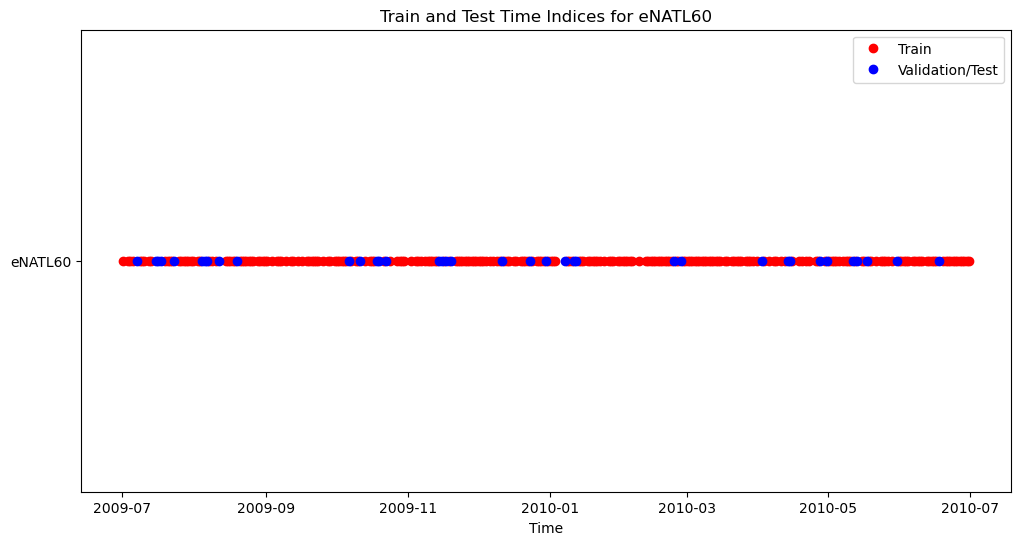

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
train_test_idx_pd = pd.to_datetime(train_season_idx)
test_season_idx_pd = pd.to_datetime(test_season_idx)

plt.figure(figsize=(12,6))
plt.plot(train_test_idx_pd, np.zeros(len(train_test_idx_pd)), 'ro', label='Train')
plt.plot(test_season_idx_pd, np.zeros(len(test_season_idx_pd)), 'bo', label='Validation/Test')
plt.yticks([0], ['eNATL60'])
plt.xlabel('Time')
plt.title('Train and Test Time Indices for eNATL60')
plt.legend()
plt.show()

In [5]:

def _split_da_along_time(
    da: xr.DataArray,
    days_ratio,
    n_gap: int = 7,
):
    """
    Subsample or split a DataArray along the time dimension.

    Parameters
    ----------
    da : xr.DataArray
        Input data with a 'time' dimension.
    days_ratio : float or tuple of floats
        - float: subsample time with step = int(1 / days_ratio)
        - tuple: return len(days_ratio) contiguous blocks whose sizes
                are proportional to the ratios and separated by n_gap
    n_gap : int
        Number of timesteps separating consecutive blocks

    Returns
    -------
    xr.DataArray or list[xr.DataArray]
    """

    if "time" not in da.dims:
        raise ValueError("DataArray must have a 'time' dimension")

    # ------------------------------------------------------------------
    # Case 1 — simple subsampling
    # ------------------------------------------------------------------
    if isinstance(days_ratio, float):
        if not (0 < days_ratio <= 1):
            raise ValueError("days_ratio must be in [0, 1]")
        step = int(1 / days_ratio)
        return da.isel(time=slice(0, None, step))

    # ------------------------------------------------------------------
    # Case 2 — contiguous block splits with gaps
    # ------------------------------------------------------------------
    if isinstance(days_ratio, tuple):
        ratios = list(days_ratio)
        n_sets = len(ratios)

        if any(r <= 0 for r in ratios):
            raise ValueError("All ratios must be positive")

        T = da.sizes["time"]
        T_eff = T - (n_sets - 1) * n_gap

        if T_eff <= 0:
            raise ValueError("n_gap too large for dataset length")

        # normalize ratios
        ratio_sum = sum(ratios)
        ratios = [r / ratio_sum for r in ratios]

        # block sizes
        block_sizes = [int(T_eff * r) for r in ratios]

        # ensure exact coverage (last block absorbs rounding)
        block_sizes[-1] += T_eff - sum(block_sizes)

        splits = []
        start = 0

        for size in block_sizes:
            end = start + size
            splits.append(da.isel(time=slice(start, end)))
            start = end + n_gap

        return splits

    raise TypeError("days_ratio must be a float or a tuple of floats")


In [3]:
enatl_da = xr.open_dataarray( "/Odyssey/public/enatl60/celerity/eNATL60_BLB002_sound_speed_regrid_0_botm.nc")

In [6]:
split = _split_da_along_time(enatl_da, days_ratio=(0.7,0.15,0.15), n_gap=7)

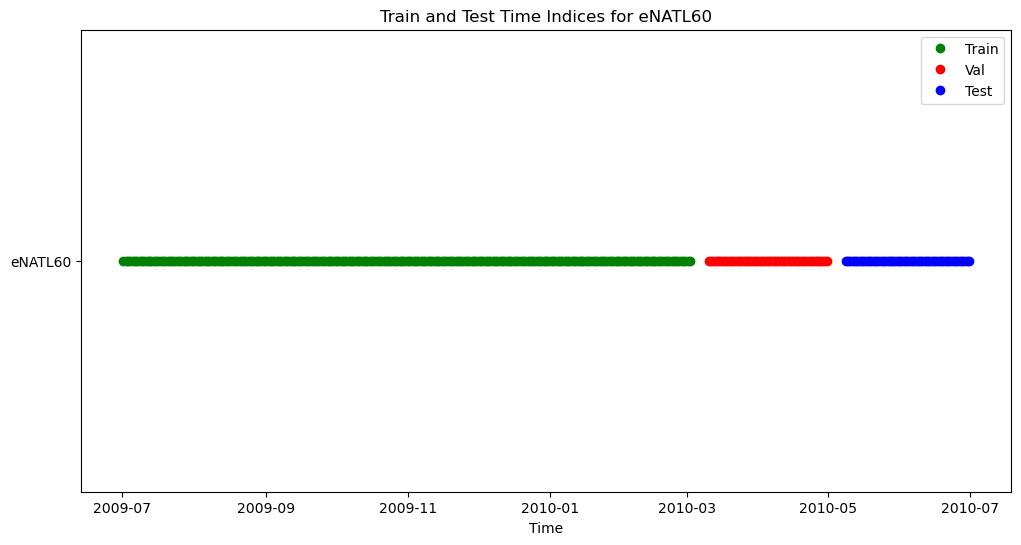

In [9]:
import pandas as pd
import matplotlib.pyplot as plt



test_season_idx_pd = pd.to_datetime(split[2].time.values)
val_season_idx_pd = pd.to_datetime(split[1].time.values)
train_season_idx_pd = pd.to_datetime(split[0].time.values)
    

plt.figure(figsize=(12,6))
plt.plot(train_season_idx_pd, np.zeros(len(train_season_idx_pd)), 'go', label='Train')
plt.plot(val_season_idx_pd, np.zeros(len(val_season_idx_pd)), 'ro', label='Val')
plt.plot(test_season_idx_pd, np.zeros(len(test_season_idx_pd)), 'bo', label='Test')
plt.yticks([0], ['eNATL60'])
plt.xlabel('Time')
plt.title('Train and Test Time Indices for eNATL60')
plt.legend()
plt.show()

In [ ]:
from tqdm import tqdm
def lagged_field_correlation(da_flat, max_lag):
    """
    da_flat: DataArray (time, space)
    """
    corrs = []

    for lag in tqdm(range(1, max_lag + 1)):
        x = da_flat.isel(time=slice(0, -lag))
        y = da_flat.isel(time=slice(lag, None))

        # Correlation over space, then average over time
        r_t = xr.corr(x, y, dim="space")   # -> (time,)
        r = r_t.mean("time")

        corrs.append(r)

    return xr.DataArray(
        corrs,
        dims="lag",
        coords={"lag": np.arange(1, max_lag + 1)},
        name="lagged_correlation"
    )


100%|██████████| 2/2 [00:52<00:00, 26.01s/it]


<xarray.DataArray 'lagged_correlation' (lag: 2)> Size: 8B
array([1., 1.], dtype=float32)
Coordinates:
  * lag      (lag) int64 16B 1 2

In [13]:
da = dm_enatl.train_ds.input
da_anom = da #da.groupby("time.dayofyear") - da.groupby("time.dayofyear").mean("time")
da_flat = da_anom.stack(space=("z", "lat", "lon"))


In [11]:
da

<xarray.DataArray 'celerity' (time: 223, z: 157, lat: 192, lon: 256)> Size: 7GB
array([[[[0.78498   , 0.7838858 , 0.78259414, ..., 0.76744795,
          0.7650575 , 0.763095  ],
         [0.7834438 , 0.78207767, 0.7805845 , ..., 0.7622421 ,
          0.7615061 , 0.760988  ],
         [0.7821145 , 0.7807587 , 0.7794847 , ..., 0.75851077,
          0.7587935 , 0.7592335 ],
         ...,
         [0.69456744, 0.69655555, 0.69731915, ..., 0.7531896 ,
          0.76314574, 0.77564454],
         [0.6519809 , 0.6588405 , 0.664013  , ..., 0.75819045,
          0.76438063, 0.7757343 ],
         [0.5887936 , 0.60562015, 0.62483925, ..., 0.7637387 ,
          0.7674575 , 0.77701604]],

        [[0.7852043 , 0.7841095 , 0.7828165 , ..., 0.76593   ,
          0.7634993 , 0.7615089 ],
         [0.78366834, 0.78229845, 0.78080153, ..., 0.7606618 ,
          0.75991064, 0.7593795 ],
         [0.78233814, 0.780978  , 0.7796998 , ..., 0.75686985,
          0.7571521 , 0.75759053],
...
          0.2775717 , 0.27823085],
         [0.27125543, 0.2699454 , 0.2693719 , ..., 0.27666426,
          0.27718937, 0.27789447],
         [0.27430543, 0.27213022, 0.2709288 , ..., 0.2761307 ,
          0.27667788, 0.27742508]],

        [[0.2918807 , 0.29082248, 0.28994814, ..., 0.29807562,
          0.29776174, 0.2974277 ],
         [0.29193377, 0.29144478, 0.29100677, ..., 0.29813427,
          0.2977805 , 0.2973025 ],
         [0.29185408, 0.29171404, 0.29155314, ..., 0.29809085,
          0.2977068 , 0.2971421 ],
         ...,
         [0.27407607, 0.2731935 , 0.27291185, ..., 0.2812991 ,
          0.28177455, 0.2824188 ],
         [0.27570167, 0.27431014, 0.27369174, ..., 0.28089318,
          0.28140417, 0.2820911 ],
         [0.27891657, 0.276585  , 0.2753023 , ..., 0.28038898,
          0.2809172 , 0.2816419 ]]]],
      shape=(223, 157, 192, 256), dtype=float32)
Coordinates:
  * z        (z) float64 1kB 0.4805 1.559 2.794 ... 1.937e+03 1.958e+03 1.98e+03
  * time     (time) datetime64[ns] 2kB 2009-07-01T12:00:00 ... 2010-02-08T12:...
  * lat      (lat) float64 2kB 32.65 32.69 32.74 32.78 ... 41.06 41.11 41.15
  * lon      (lon) float64 2kB -65.95 -65.9 -65.86 ... -54.09 -54.05 -54.0
Attributes:
    season_idx:             [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...
    original_space_coords:  {'lat': <xarray.DataArray 'lat' (lat: 140)> Size:...
    sst:                    <xarray.DataArray 'sst' (time: 223, lat: 192, lon...

In [6]:
np.isnan(da_flat.data).any()

np.False_

100%|██████████| 60/60 [18:42<00:00, 18.71s/it]


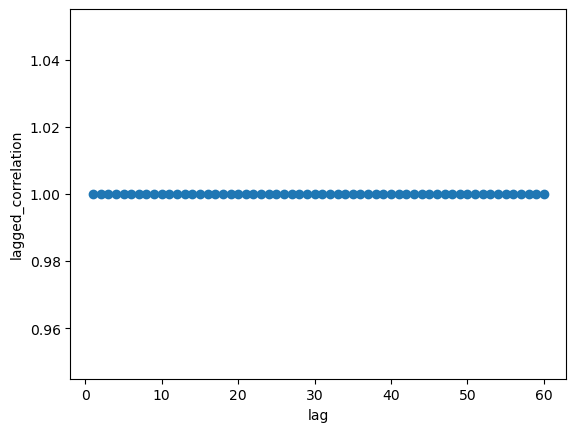

In [16]:
corr_da = lagged_field_correlation(da_flat, max_lag=60)
corr_da.plot(marker="o")

In [21]:
print(train_season_idx_pd.min(), train_season_idx_pd.max())
print(val_season_idx_pd.min(), val_season_idx_pd.max())
print(test_season_idx_pd.min(), test_season_idx_pd.max())

2009-07-01 12:00:00 2010-02-08 12:00:00
2010-02-16 12:00:00 2010-03-18 12:00:00
2010-03-26 12:00:00 2010-06-30 12:00:00


In [22]:
print(dm_enatl.train_shape[0], dm_enatl.val_shape[0], dm_enatl.test_shape[0])

223 31 97


In [24]:
223+31+97

351

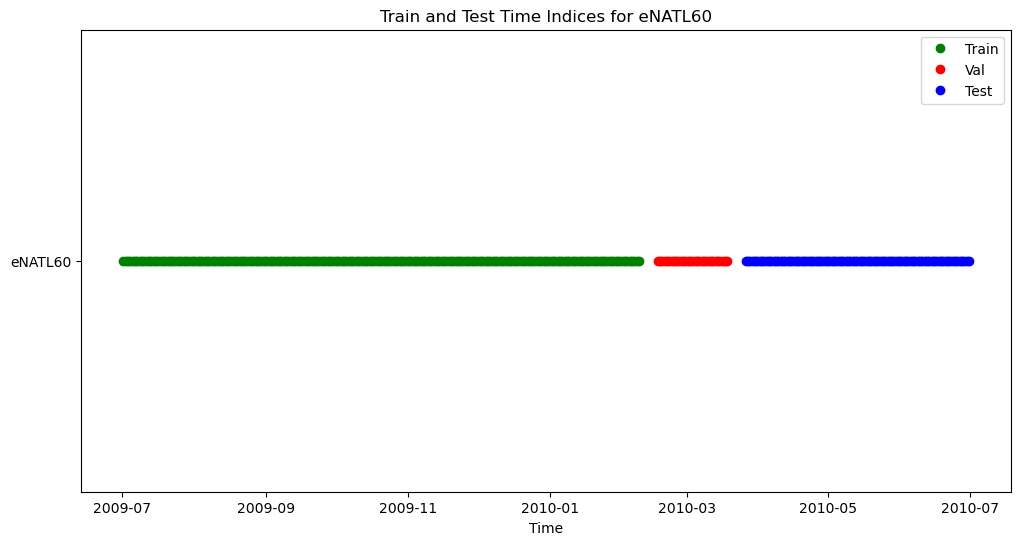

In [19]:
import pandas as pd
import matplotlib.pyplot as plt



test_season_idx_pd = pd.to_datetime(dm_enatl.test_ds.input.time.values)
val_season_idx_pd = pd.to_datetime(dm_enatl.val_ds.input.time.values)
train_season_idx_pd = pd.to_datetime(dm_enatl.train_ds.input.time.values)
    

plt.figure(figsize=(12,6))
plt.plot(train_season_idx_pd, np.zeros(len(train_season_idx_pd)), 'go', label='Train')
plt.plot(val_season_idx_pd, np.zeros(len(val_season_idx_pd)), 'ro', label='Val')
plt.plot(test_season_idx_pd, np.zeros(len(test_season_idx_pd)), 'bo', label='Test')
plt.yticks([0], ['eNATL60'])
plt.xlabel('Time')
plt.title('Train and Test Time Indices for eNATL60')
plt.legend()
plt.show()

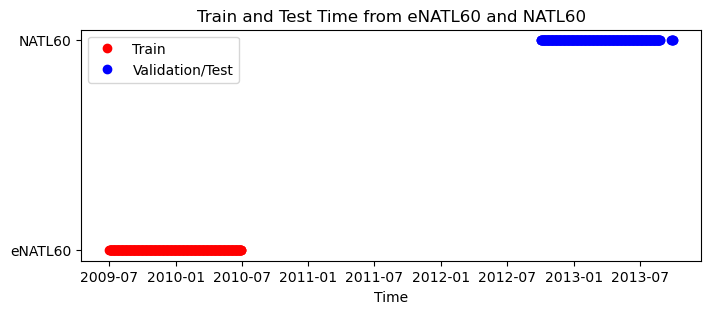

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
train_test_idx_pd = pd.to_datetime(dm_mlic.train_da.time.values)
test_season_idx_pd = pd.to_datetime(dm_mlic.test_da.time.values)

plt.figure(figsize=(8,3))
plt.plot(train_test_idx_pd, np.zeros(len(train_test_idx_pd)), 'ro', label='Train')
plt.plot(test_season_idx_pd, np.ones(len(test_season_idx_pd)), 'bo', label='Validation/Test')
plt.yticks([0,1], ['eNATL60', "NATL60"])
plt.xlabel('Time')
plt.title('Train and Test Time from eNATL60 and NATL60')
plt.legend()
plt.show()

In [33]:
enatl_test_truth_da.data.shape,enatl_train_truth_da.data.shape

((37, 157, 140, 240), (255, 157, 140, 240))

In [36]:
from scipy.stats import pearsonr
pearsonr(enatl_test_truth_da.data.mean(axis=(0,2,3)), enatl_train_truth_da.data.mean(axis=(0,2,3)))

PearsonRResult(statistic=np.float32(0.13738771), pvalue=np.float64(0.08618887248514406))

In [18]:
np.corrcoef(enatl_test_truth_da.data.mean(axis=(0,2,3)), enatl_train_truth_da.data.mean(axis=(0,2,3)))

array([[1.        , 0.13738769],
       [0.13738769, 1.        ]])

In [19]:
np.corrcoef(dm_mlic.train_da.data.mean(axis=(0,2,3)), dm_mlic.test_da.data.mean(axis=(0,2,3)))

array([[1.       , 0.9958606],
       [0.9958606, 1.       ]])

In [44]:
enatl_test_truth_da.data.mean(axis=(2,3)).shape

(37, 157)

In [45]:
np.corrcoef(enatl_test_truth_da.data.mean(axis=(1,2,3)), enatl_train_truth_da.data.mean(axis=(1,2,3)))

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 37 and the array at index 1 has size 255

In [20]:
A = enatl_test_truth_da.data.mean(axis=(2,3))   # shape (37, 157)
B = enatl_train_truth_da.data.mean(axis=(2,3))  # shape (255, 157)
# Normalize rows
A_norm = (A - A.mean(axis=1, keepdims=True)) / A.std(axis=1, keepdims=True)
B_norm = (B - B.mean(axis=1, keepdims=True)) / B.std(axis=1, keepdims=True)

# Cross-correlation matrix (37×255)
corr = A_norm @ B_norm.T / A.shape[1]


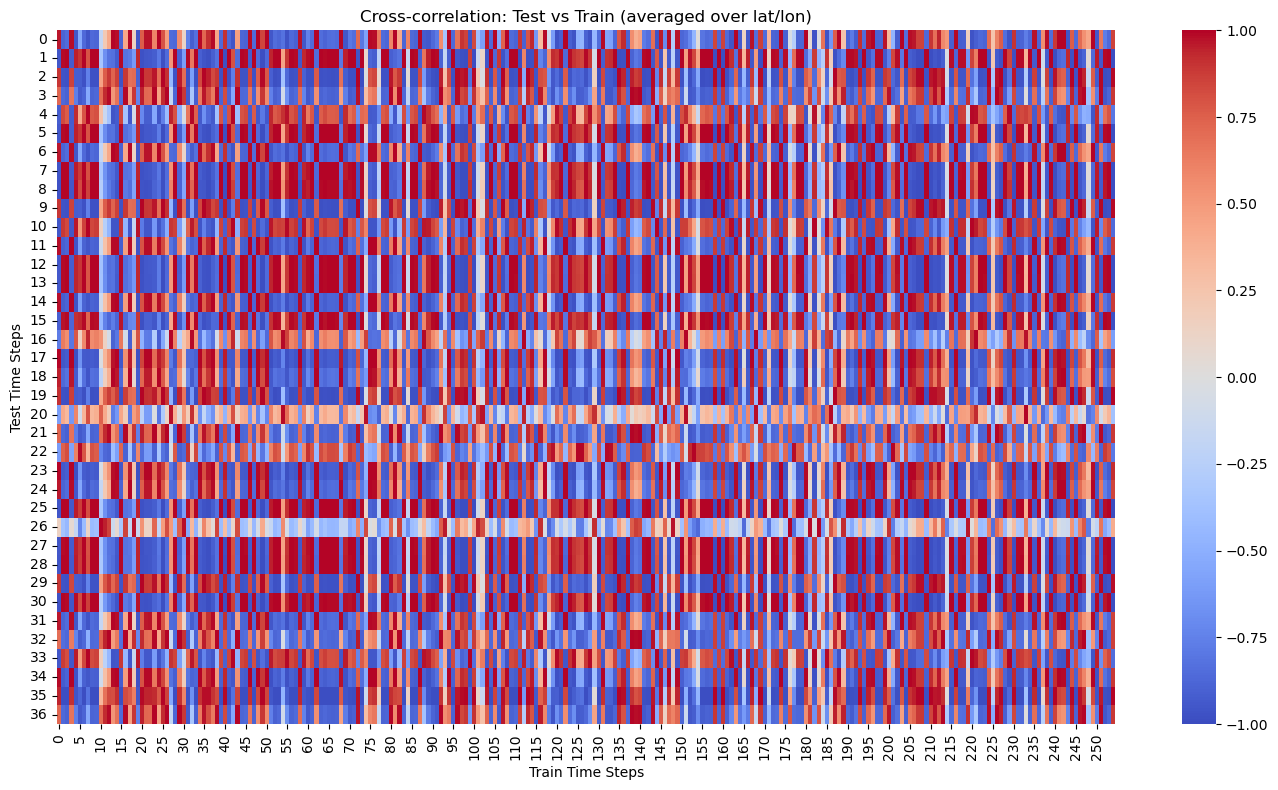

In [21]:
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.xlabel('Train Time Steps')
plt.ylabel('Test Time Steps')
plt.title('Cross-correlation: Test vs Train (averaged over lat/lon)')
plt.tight_layout()
plt.show()

In [22]:
A = dm_mlic.train_da.data.mean(axis=(2,3))   # shape (37, 157)
B = dm_mlic.test_da.data.mean(axis=(2,3))  # shape (255, 157)
# Normalize rows
A_norm = (A - A.mean(axis=1, keepdims=True)) / A.std(axis=1, keepdims=True)
B_norm = (B - B.mean(axis=1, keepdims=True)) / B.std(axis=1, keepdims=True)

# Cross-correlation matrix (37×255)
corr = A_norm @ B_norm.T / A.shape[1]


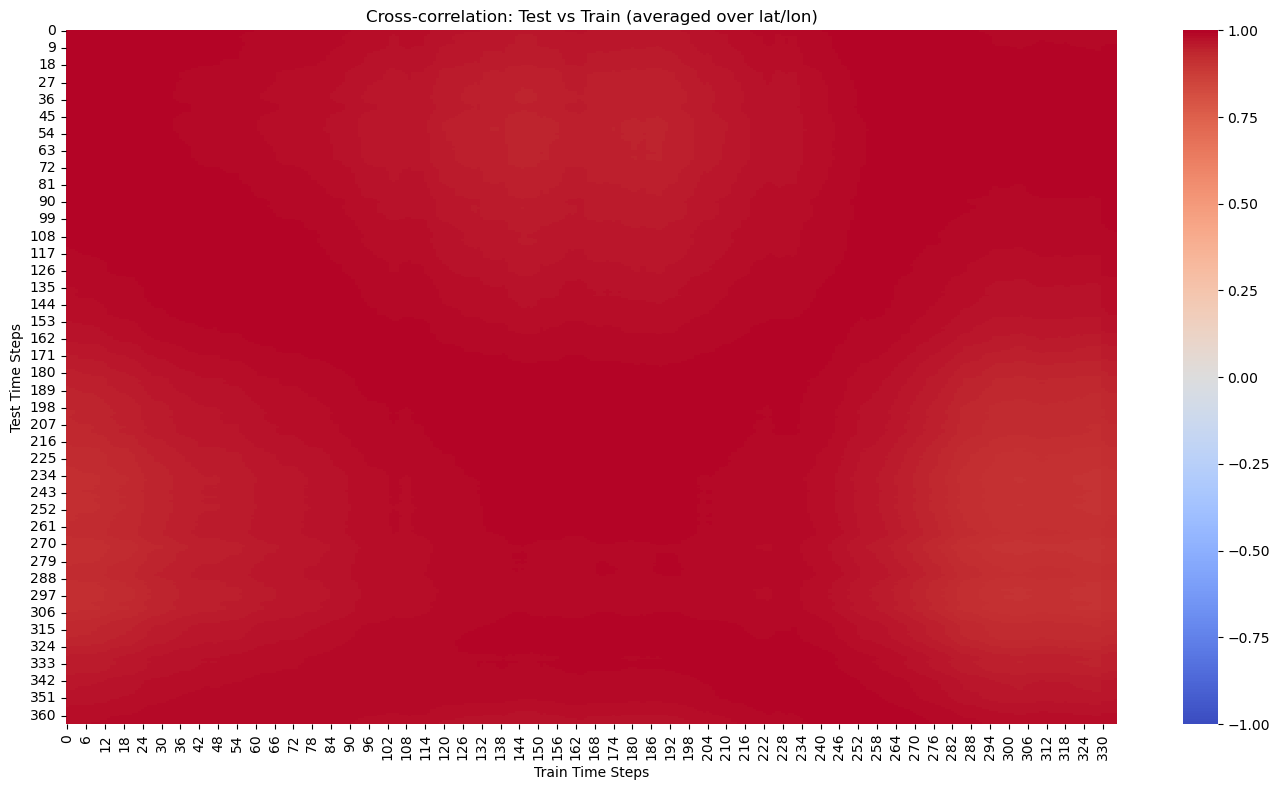

In [24]:
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.xlabel('Train Time Steps')
plt.ylabel('Test Time Steps')
plt.title('Cross-correlation: Test vs Train (averaged over lat/lon)')
plt.tight_layout()
plt.show()

In [23]:
natl_test_data = xr.open_dataarray("/Odyssey/public/natl60/celerity/NATL60GULF-CJM165_sound_speed_regrid_0_botm.nc").isel(time=dm_cae.test_time_idx,method='nearest')

ValueError: Dimensions {'method'} do not exist. Expected one or more of FrozenMappingWarningOnValuesAccess({'lon': 240, 'lat': 240, 'z': 300, 'time': 335})